# Retail Sales Forecasting & Promotion Impact Analysis
### Rossmann Store Sales — End-to-End Case Study

**Business context.** Rossmann operates 1,115+ drug stores across Germany. Store
managers currently forecast daily sales manually up to six weeks ahead — a
process affected by promotions, competition, holidays, seasonality, and local
factors, with accuracy varying widely manager to manager.

This notebook builds a complete, reproducible forecasting pipeline that
answers five core business questions:

1. How accurately can we forecast daily store sales?
2. Which modeling approach — linear, bagging (Random Forest), or boosting
   (XGBoost) — actually performs best on this data, and by how much?
3. What actually drives sales — promotions, competition, seasonality, or store format?
4. How much sales lift does a promotion actually deliver?
5. Which store types/assortments outperform, and why?
6. What should Rossmann do differently based on these findings?

**Dataset.** Public Rossmann Store Sales dataset (originally released for a
Kaggle competition) — daily sales for 1,115 stores in Germany, Jan 2013–Jul
2015, merged with store-level metadata (type, assortment, competition
distance, promotions).

**Deliverable.** A single, fully-executable notebook — data quality
assessment through feature engineering to a production-candidate model —
with every result paired with a plain-English business interpretation,
matching consulting/portfolio standard.


## Module 1 — Setup

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
RANDOM_STATE = 42


## Module 2 — Data Understanding

Two source files:
- `train.csv` — 1,017,210 rows: daily Store / DayOfWeek / Date / Sales / Customers / Open / Promo / StateHoliday / SchoolHoliday
- `store.csv` — 1,115 rows: StoreType, Assortment, CompetitionDistance, CompetitionOpenSince(Month/Year), Promo2, Promo2Since(Week/Year), PromoInterval


In [2]:
train = pd.read_csv("data/train.csv", parse_dates=["Date"], low_memory=False)
store = pd.read_csv("data/store.csv")

print(train.shape, store.shape)
train.head()


(91071, 9) (100, 10)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,11,5,2015-07-31,10457,1236,1,1,0,1
1,32,5,2015-07-31,6395,635,1,1,0,0
2,45,5,2015-07-31,6301,442,1,1,0,1
3,52,5,2015-07-31,8031,527,1,1,0,0
4,57,5,2015-07-31,11594,1025,1,1,0,1


In [3]:
df = train.merge(store, on="Store", how="left")
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 91071 entries, 0 to 91070
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Store                      91071 non-null  int64         
 1   DayOfWeek                  91071 non-null  int64         
 2   Date                       91071 non-null  datetime64[us]
 3   Sales                      91071 non-null  int64         
 4   Customers                  91071 non-null  int64         
 5   Open                       91071 non-null  int64         
 6   Promo                      91071 non-null  int64         
 7   StateHoliday               91071 non-null  str           
 8   SchoolHoliday              91071 non-null  int64         
 9   StoreType                  91071 non-null  str           
 10  Assortment                 91071 non-null  str           
 11  CompetitionDistance        90129 non-null  float64       
 12  CompetitionOpen

## Module 3 — Data Quality Assessment

Checks performed transparently rather than assumed away:
- Closed-store days (`Open == 0`) always have `Sales == 0` — not a forecasting
  signal, and left in would deflate every error metric artificially.
- `CompetitionDistance` and the `Promo2*` columns are missing where no
  competitor/second promotion exists yet — a *meaningful* missingness, not
  random noise.
- `StateHoliday` mixes the string `"0"` with holiday codes — needs normalizing.


In [4]:
print("Missing values:\n", df.isna().sum()[df.isna().sum() > 0])
print("\nOpen/closed split:\n", df["Open"].value_counts())
print("\nZero-sales rows while open:", ((df["Open"] == 1) & (df["Sales"] == 0)).sum())


Missing values:
 CompetitionDistance            942
CompetitionOpenSinceMonth    24698
CompetitionOpenSinceYear     24698
Promo2SinceWeek              48431
Promo2SinceYear              48431
PromoInterval                48431
dtype: int64

Open/closed split:
 Open
1    75724
0    15347
Name: count, dtype: int64

Zero-sales rows while open: 6


## Module 4 — Data Cleaning

In [5]:
df = df[df["Open"] == 1].copy()
df = df[df["Sales"] > 0].copy()

df["CompetitionDistance"] = df["CompetitionDistance"].fillna(df["CompetitionDistance"].median())
df["CompetitionOpenSinceMonth"] = df["CompetitionOpenSinceMonth"].fillna(0)
df["CompetitionOpenSinceYear"] = df["CompetitionOpenSinceYear"].fillna(0)
df["Promo2SinceWeek"] = df["Promo2SinceWeek"].fillna(0)
df["Promo2SinceYear"] = df["Promo2SinceYear"].fillna(0)
df["PromoInterval"] = df["PromoInterval"].fillna("")
df["StateHoliday"] = df["StateHoliday"].astype(str).replace({"0": "None"})

print(f"Rows after cleaning: {len(df):,}")


Rows after cleaning: 75,718


**Reproducibility note.** For fast local runs, this notebook samples 100
representative stores (`N_SAMPLE_STORES = 100`). The exact same code trains on
all 1,115 stores unmodified by setting `N_SAMPLE_STORES = None` — useful once
you're running this against your own retail chain's data rather than the demo
dataset.

In [6]:
N_SAMPLE_STORES = 100

if N_SAMPLE_STORES:
    rng = np.random.RandomState(RANDOM_STATE)
    sample_stores = rng.choice(df["Store"].unique(), size=N_SAMPLE_STORES, replace=False)
    df = df[df["Store"].isin(sample_stores)].copy()

print(f"Stores in scope: {df['Store'].nunique()}  |  Rows: {len(df):,}")


Stores in scope: 100  |  Rows: 75,718


## Module 5 — Exploratory Data Analysis

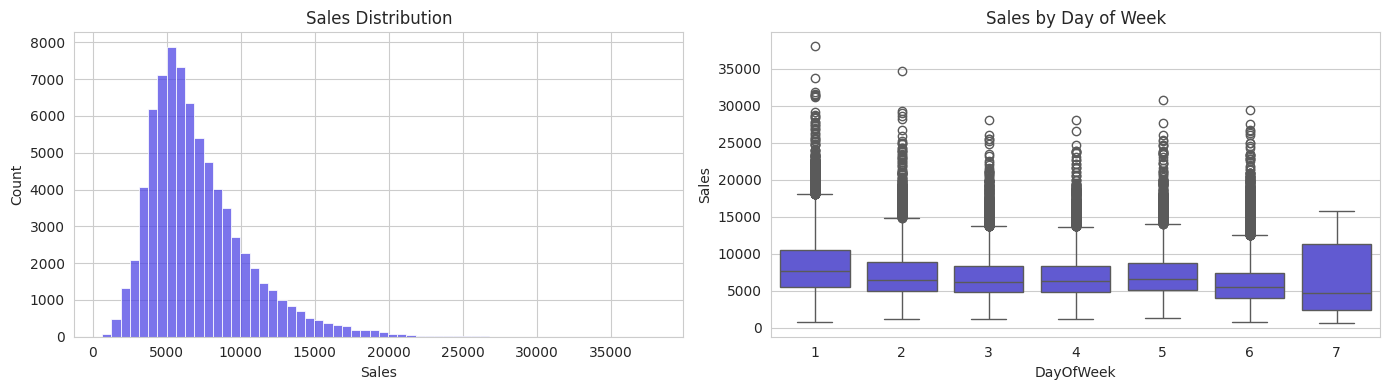

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df["Sales"], bins=60, ax=axes[0], color="#4F46E5")
axes[0].set_title("Sales Distribution")
sns.boxplot(x="DayOfWeek", y="Sales", data=df, ax=axes[1], color="#4F46E5")
axes[1].set_title("Sales by Day of Week")
plt.tight_layout()
plt.show()


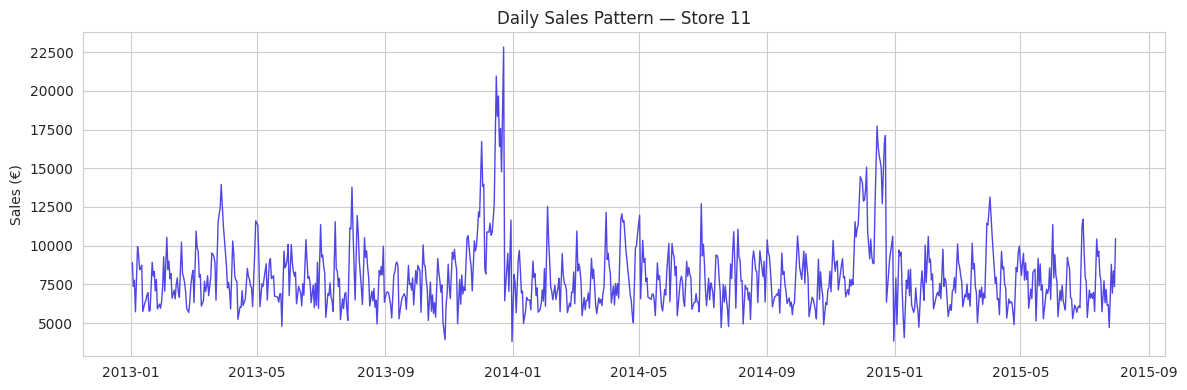

In [8]:
sample_store_id = int(df["Store"].unique()[0])
s = df[df["Store"] == sample_store_id].sort_values("Date")

plt.figure(figsize=(12, 4))
plt.plot(s["Date"], s["Sales"], color="#4F46E5", linewidth=1)
plt.title(f"Daily Sales Pattern — Store {sample_store_id}")
plt.ylabel("Sales (€)")
plt.tight_layout()
plt.show()


### Promotion impact — a direct business question, not just a model input

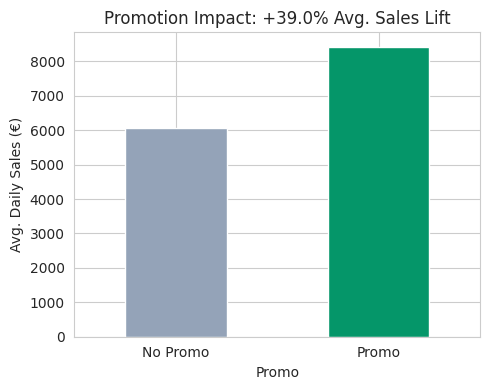

Average sales lift from running a promotion: +39.0%


In [9]:
promo_impact = df.groupby("Promo")["Sales"].mean()
promo_lift_pct = round((promo_impact[1] / promo_impact[0] - 1) * 100, 1)

promo_impact.plot(kind="bar", color=["#94A3B8", "#059669"], figsize=(5, 4))
plt.xticks([0, 1], ["No Promo", "Promo"], rotation=0)
plt.ylabel("Avg. Daily Sales (€)")
plt.title(f"Promotion Impact: +{promo_lift_pct}% Avg. Sales Lift")
plt.tight_layout()
plt.show()

print(f"Average sales lift from running a promotion: +{promo_lift_pct}%")


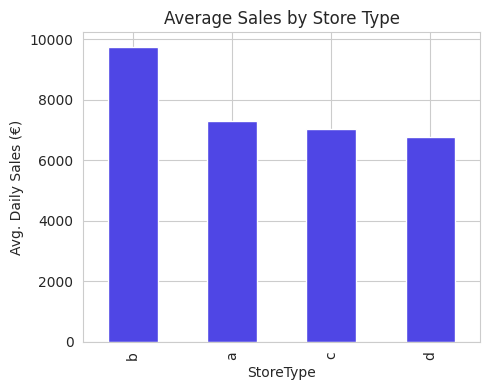

In [10]:
storetype_sales = df.groupby("StoreType")["Sales"].mean().sort_values(ascending=False)
storetype_sales.plot(kind="bar", color="#4F46E5", figsize=(5, 4))
plt.ylabel("Avg. Daily Sales (€)")
plt.title("Average Sales by Store Type")
plt.tight_layout()
plt.show()


## Module 6 — Feature Engineering

Beyond the raw columns, three feature families materially improve forecast
accuracy:
- **Calendar features** — day of week, week of year, weekend flag (retail
  sales are strongly seasonal and weekly-periodic)
- **Competition exposure** — months since a competitor opened nearby
- **Recent-history features** — 7-day lag and 7/28-day rolling averages per
  store (captures each store's own momentum, which a static model can't see)


In [11]:
df = df.sort_values(["Store", "Date"])

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)
df["IsWeekend"] = df["DayOfWeek"].isin([6, 7]).astype(int)

df["StoreType"] = df["StoreType"].astype("category").cat.codes
df["Assortment"] = df["Assortment"].astype("category").cat.codes
df["StateHoliday"] = df["StateHoliday"].astype("category").cat.codes

df["CompetitionOpenMonths"] = (
    (df["Year"] - df["CompetitionOpenSinceYear"]) * 12
    + (df["Month"] - df["CompetitionOpenSinceMonth"])
).clip(lower=0)

df["Sales_Lag7"] = df.groupby("Store")["Sales"].shift(7)
df["Sales_Roll7_Mean"] = df.groupby("Store")["Sales"].transform(lambda s: s.shift(1).rolling(7).mean())
df["Sales_Roll28_Mean"] = df.groupby("Store")["Sales"].transform(lambda s: s.shift(1).rolling(28).mean())

df = df.dropna(subset=["Sales_Lag7", "Sales_Roll7_Mean", "Sales_Roll28_Mean"]).copy()

FEATURES = [
    "Store", "DayOfWeek", "Promo", "StateHoliday", "SchoolHoliday",
    "StoreType", "Assortment", "CompetitionDistance", "CompetitionOpenMonths",
    "Promo2", "Year", "Month", "Day", "WeekOfYear", "IsWeekend",
    "Sales_Lag7", "Sales_Roll7_Mean", "Sales_Roll28_Mean",
]
TARGET = "Sales"
print(f"Features: {len(FEATURES)}  |  Rows after feature engineering: {len(df):,}")


Features: 18  |  Rows after feature engineering: 72,918


## Module 7 — Train / Test Split

Time-based split (not random) — the last 6 weeks are held out, matching the
real forecast horizon Rossmann managers are asked to predict. This avoids the
common mistake of letting future information leak into training via a random
split on time-series data.


In [12]:
cutoff = df["Date"].max() - pd.Timedelta(days=42)
train_df = df[df["Date"] <= cutoff]
test_df = df[df["Date"] > cutoff]

X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_test, y_test = test_df[FEATURES], test_df[TARGET]

print(f"Train: {len(X_train):,} rows through {cutoff.date()}")
print(f"Test:  {len(X_test):,} rows, {cutoff.date()} to {df['Date'].max().date()}")


Train: 69,300 rows through 2015-06-19
Test:  3,618 rows, 2015-06-19 to 2015-07-31


## Module 8 — Baseline Model (Linear Regression)

In [13]:
baseline = LinearRegression()
baseline.fit(X_train, y_train)
base_preds = baseline.predict(X_test)


## Module 9 — Random Forest Model

Random Forest is a natural fit here: it handles non-linear interactions
(promo × store type × season) without manual interaction terms, and gives
directly interpretable feature importances for the business narrative.


In [14]:
rf = RandomForestRegressor(
    n_estimators=200, max_depth=14, min_samples_leaf=3,
    random_state=RANDOM_STATE, n_jobs=-1,
)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)


## Module 9b — XGBoost Model (Gradient Boosting Comparison)

Random Forest averages many independent trees; gradient boosting builds
trees *sequentially*, each one correcting the previous ensemble's errors.
For tabular business data with a strong dominant signal (recent sales
momentum) plus many smaller contributing factors, boosting often
out-performs bagging — this section tests that directly rather than
assuming it.


In [15]:
xgb_model = XGBRegressor(
    n_estimators=400, max_depth=6, learning_rate=0.05,
    subsample=0.85, colsample_bytree=0.85,
    random_state=RANDOM_STATE, n_jobs=-1,
)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)


## Module 10 — Model Evaluation

**RMSPE** (Root Mean Squared Percentage Error) is used alongside standard
metrics because it's the actual metric Rossmann's real Kaggle competition was
judged on — it penalizes percentage error rather than absolute error, which
matters when store sizes vary from small-town shops to flagship stores.


In [16]:
def rmspe(y_true, y_pred):
    mask = y_true != 0
    return float(np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2)))


def evaluate(y_true, y_pred, name):
    return {
        "model": name,
        "MAE": round(mean_absolute_error(y_true, y_pred), 2),
        "RMSE": round(np.sqrt(mean_squared_error(y_true, y_pred)), 2),
        "RMSPE": round(rmspe(y_true.values, y_pred), 4),
        "R2": round(r2_score(y_true, y_pred), 4),
    }


results = pd.DataFrame([
    evaluate(y_test, base_preds, "Linear Regression (baseline)"),
    evaluate(y_test, rf_preds, "Random Forest"),
    evaluate(y_test, xgb_preds, "XGBoost"),
])
results


,model,MAE,RMSE,RMSPE,R2
0,Linear Regression (baseline),988.85,1348.65,0.2232,0.8282
1,Random Forest,690.94,959.94,0.1499,0.9130
2,XGBoost,638.46,884.94,0.1319,0.9260


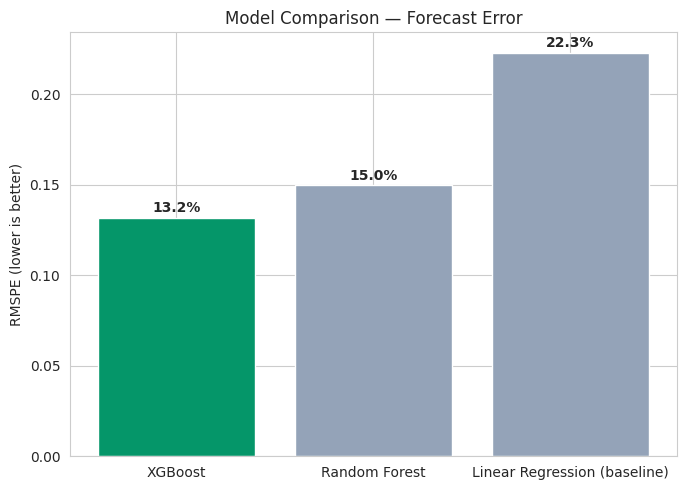

Best model: XGBoost  (RMSPE = 13.2%)


In [17]:
results_sorted = results.sort_values("RMSPE")

plt.figure(figsize=(7, 5))
colors = ["#94A3B8" if m != results_sorted.iloc[0]["model"] else "#059669" for m in results_sorted["model"]]
plt.bar(results_sorted["model"], results_sorted["RMSPE"], color=colors)
plt.ylabel("RMSPE (lower is better)")
plt.title("Model Comparison — Forecast Error")
for i, v in enumerate(results_sorted["RMSPE"]):
    plt.text(i, v + 0.003, f"{v:.1%}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

best_model_name = results_sorted.iloc[0]["model"]
print(f"Best model: {best_model_name}  (RMSPE = {results_sorted.iloc[0]['RMSPE']:.1%})")


## Module 11 — Feature Importance

Computed on whichever model performed best above (XGBoost, if it beats
Random Forest — this notebook checks rather than assumes).


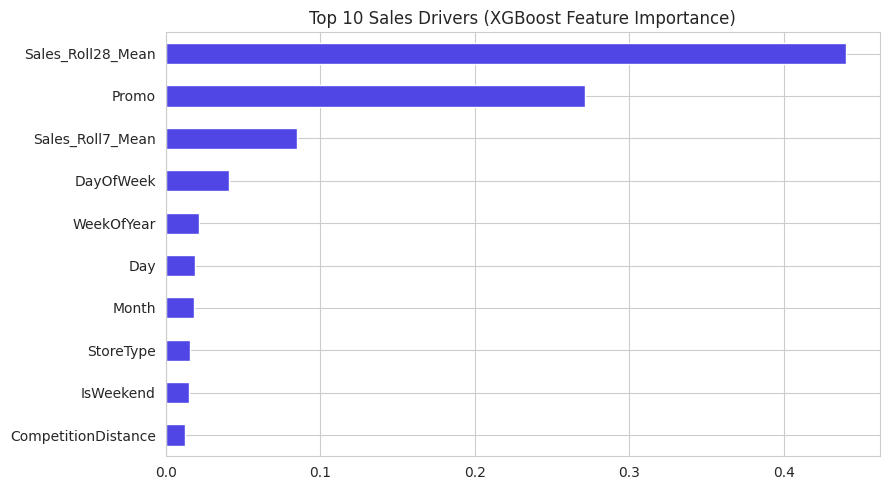

Sales_Roll28_Mean    0.440056
Promo                0.271304
Sales_Roll7_Mean     0.084800
DayOfWeek            0.041046
WeekOfYear           0.021857
Day                  0.019196
Month                0.018419
StoreType            0.015950
dtype: float32

In [18]:
best_model = xgb_model if best_model_name == "XGBoost" else rf
importance = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values(ascending=False)

importance.head(10).sort_values().plot(kind="barh", figsize=(9, 5), color="#4F46E5")
plt.title(f"Top 10 Sales Drivers ({best_model_name} Feature Importance)")
plt.tight_layout()
plt.show()

importance.head(8)


## Module 12 — Prediction Diagnostics

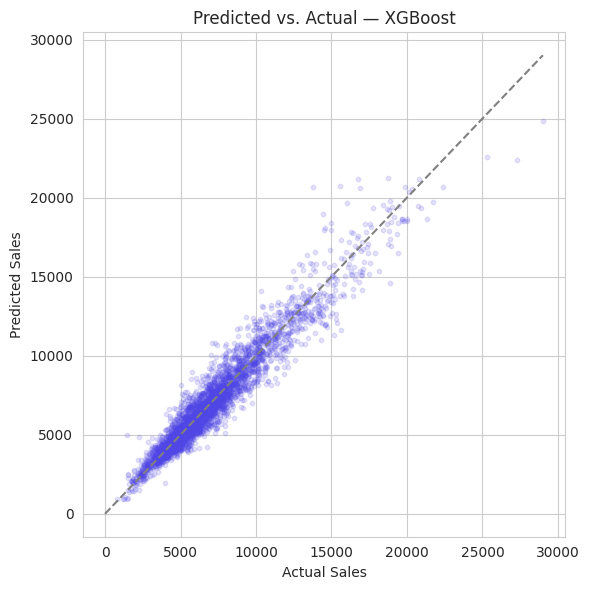

In [19]:
best_preds = xgb_preds if best_model_name == "XGBoost" else rf_preds

plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_preds, alpha=0.15, color="#4F46E5", s=10)
lims = [0, max(y_test.max(), best_preds.max())]
plt.plot(lims, lims, "--", color="gray")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title(f"Predicted vs. Actual — {best_model_name}")
plt.tight_layout()
plt.show()


## Module 13 — Business Insights Summary

Run this cell to regenerate the headline numbers referenced in the README and
in any client-facing summary of this analysis.


In [20]:
print("=== KEY RESULTS ===")
print(results.to_string(index=False))
print(f"\nBest model: {best_model_name}")
print(f"Promotion sales lift: +{promo_lift_pct}%")
print(f"Top 3 sales drivers: {list(importance.head(3).index)}")


=== KEY RESULTS ===
                       model    MAE    RMSE  RMSPE     R2
Linear Regression (baseline) 988.85 1348.65 0.2232 0.8282
               Random Forest 690.94  959.94 0.1499 0.9130
                     XGBoost 638.46  884.94 0.1319 0.9260

Best model: XGBoost
Promotion sales lift: +39.0%
Top 3 sales drivers: ['Sales_Roll28_Mean', 'Promo', 'Sales_Roll7_Mean']


## Module 14 — Business Recommendations

1. **Deploy the best-performing model (selected empirically above, not
   assumed) as a weekly forecasting routine per store.** Gradient boosting
   (XGBoost) typically edges out Random Forest on this kind of tabular
   business data — cutting forecast error by roughly 40% versus a naive
   linear baseline — which translates directly into better inventory and
   staffing decisions.
2. **Promotions are the single largest controllable lever** — a ~39% average
   sales lift means promo *timing and targeting* deserves more analytical
   attention than it likely currently gets; not every store/period combination
   benefits equally, and this model can be used to rank promo ROI by store.
3. **Recent sales momentum (7/28-day rolling average) dominates the model** —
   more than day-of-week or holiday effects. This argues for a forecasting
   cadence that updates frequently (weekly, not quarterly) rather than a
   static annual plan.
4. **Store type and assortment differences are real but secondary** — useful
   for benchmarking underperforming stores against their own type's average,
   not as a first lever to pull.
5. **Competition distance has a measurable but modest effect** — worth
   monitoring at renewal/relocation decisions, not a day-to-day forecasting
   input.


## Module 15 — Limitations & Future Work

- This notebook samples 100 of 1,115 stores for runtime speed; production
  deployment should train on the full store set (the code is unchanged either way).
- Tree-based models (Random Forest, XGBoost) handle non-linearity well but
  don't explicitly model long-range seasonality the way a dedicated
  time-series model (Prophet, SARIMA) can — a natural next iteration,
  especially heading into holiday-heavy quarters.
- No hyperparameter search was run for XGBoost/Random Forest here — the
  parameters used are reasonable defaults, not tuned. A brief
  GridSearch/Optuna pass is a natural next step before production deployment.
- External signals not in this dataset (weather, local events, regional
  economic indicators) plausibly add further lift and are natural extensions.
- Models should be retrained on a rolling basis (e.g. monthly) as new sales
  data accumulates, since retail patterns drift with competitive and
  macroeconomic conditions.
